In [1]:
import numpy as np
import pandas as pd
from numpy import mean
from numpy import std

import matplotlib.pyplot as plt

In [2]:
import seaborn as sns
%matplotlib inline

In [3]:
data = pd.read_csv("./../data/Salaries.csv")
data.columns

Index(['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency',
       'Status'],
      dtype='object')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148045 non-null  float64
 4   OvertimePay       148650 non-null  float64
 5   OtherPay          148650 non-null  float64
 6   Benefits          112491 non-null  float64
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  object 
 12  Status            0 non-null       float64
dtypes: float64(8), int64(2), object(3)
memory usage: 14.7+ MB


dpi → dots per inch (inç başına düşen nokta sayısı)

<Axes: xlabel='TotalPay', ylabel='BasePay'>

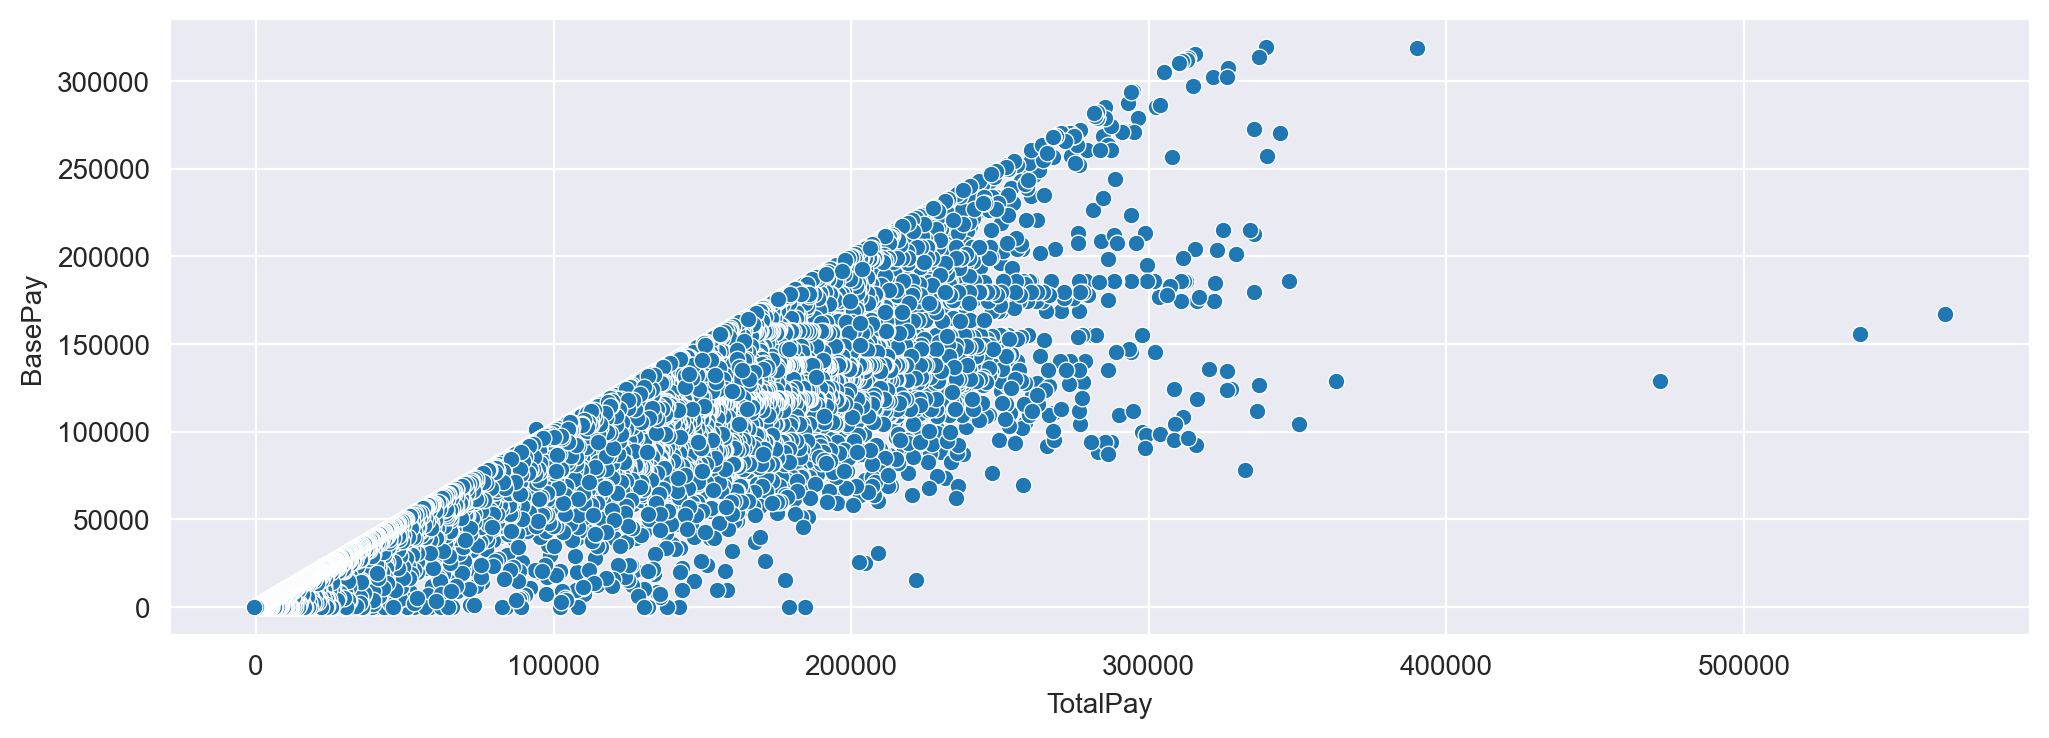

In [5]:
plt.figure(figsize=(12,4), dpi=200)
sns.scatterplot(x='TotalPay', y='BasePay', data=data)

<Axes: xlabel='TotalPay', ylabel='OvertimePay'>

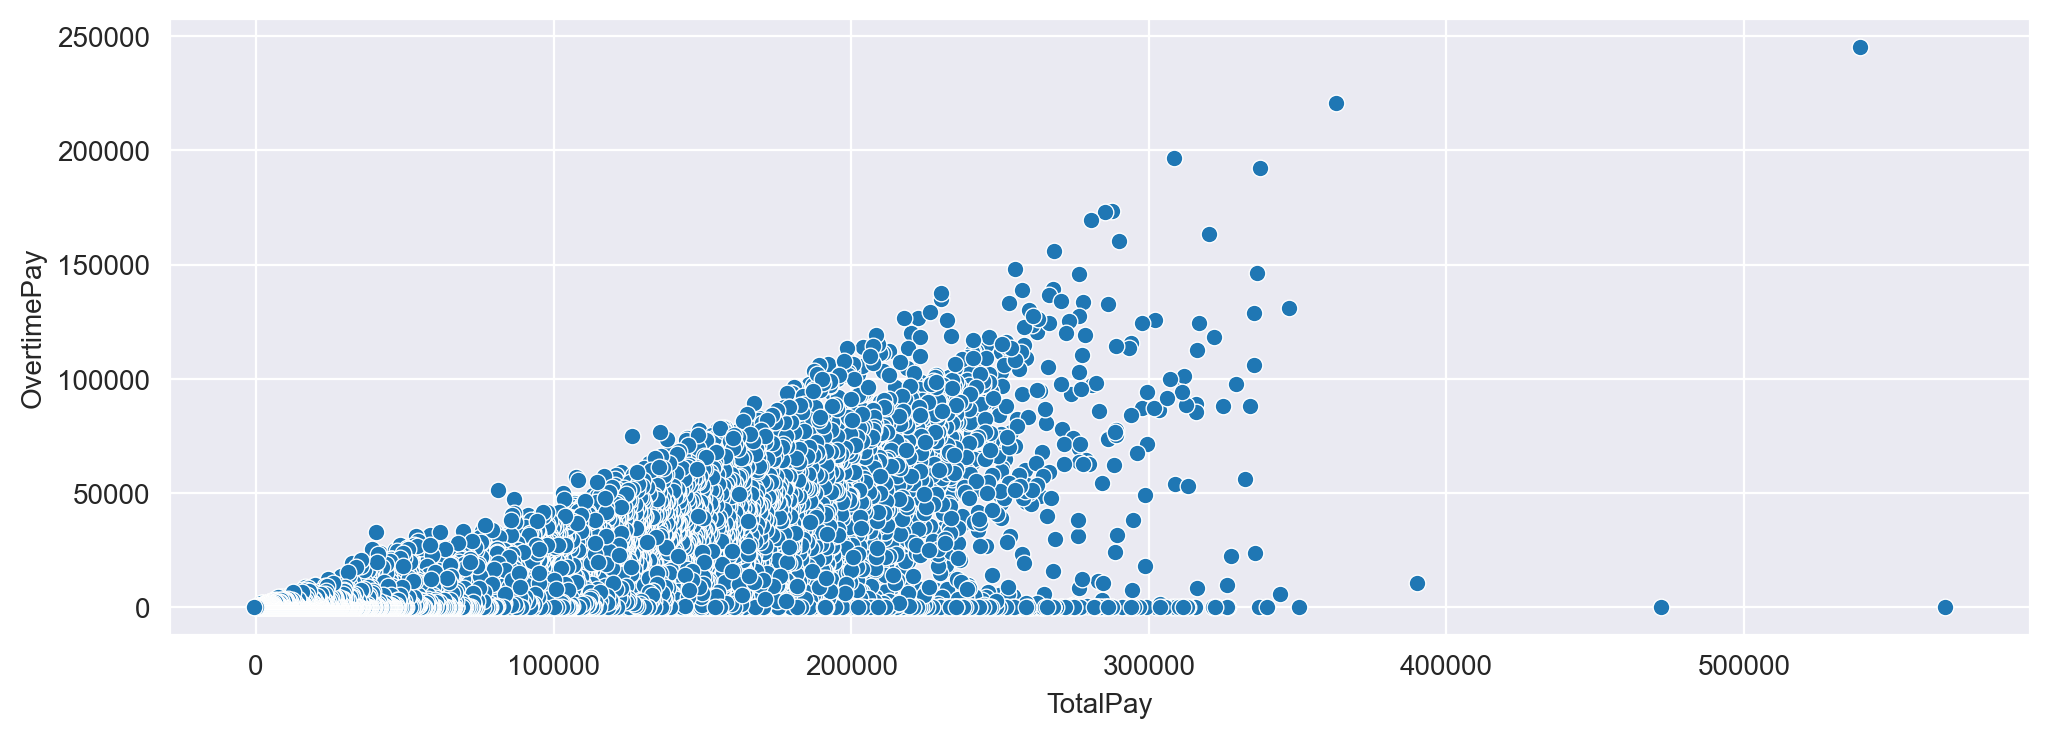

In [6]:
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(x='TotalPay', y='OvertimePay',data = data)

<Axes: xlabel='TotalPay', ylabel='OvertimePay'>

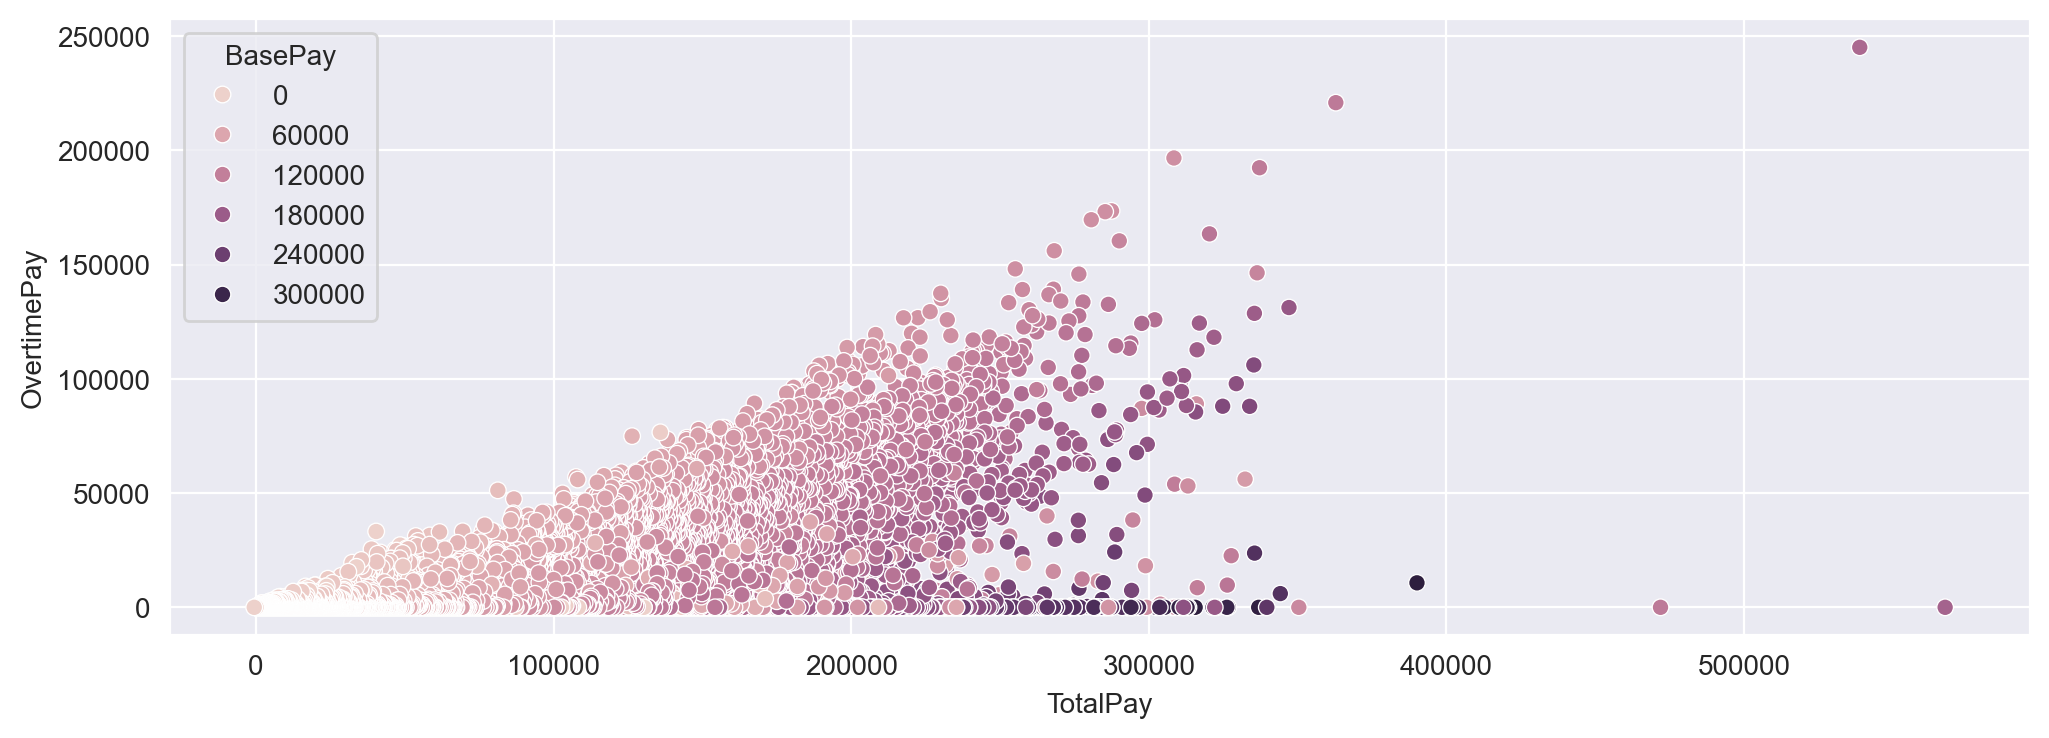

In [7]:
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(x='TotalPay', y='OvertimePay',data = data,hue='BasePay')

<Axes: ylabel='Frequency'>

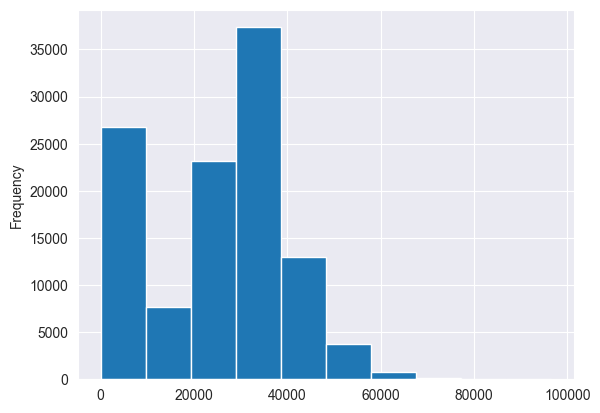

In [8]:
year = data['Benefits']

year.plot(kind='hist')

[]

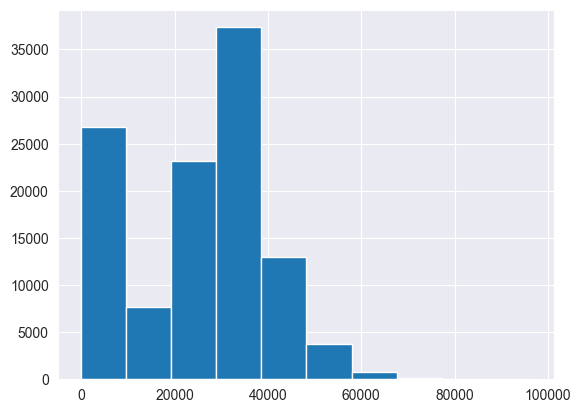

In [28]:
plt.hist(year)
plt.plot()

## displot

A Distplot or distribution plot, depicts the variation in the data distribution. Seaborn Displot represents the overall distribution of continuous data variables. The Displot depicts the data by a histogram and a line in combination to it.

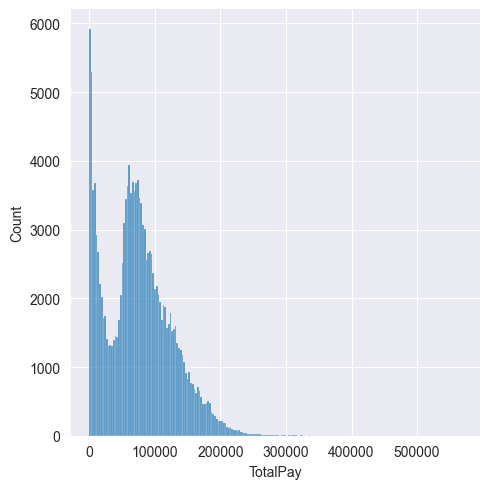

In [10]:
sns.displot(data['TotalPay'])

## Bins

The bins parameter enables you to control the bins of the histogram (i.e., the number of bars). The most common way to do this is to set the number of bins by providing an integer as the argument to the parameter. For example, if you set bins = 30 , the function will create a histogram with 30 bars

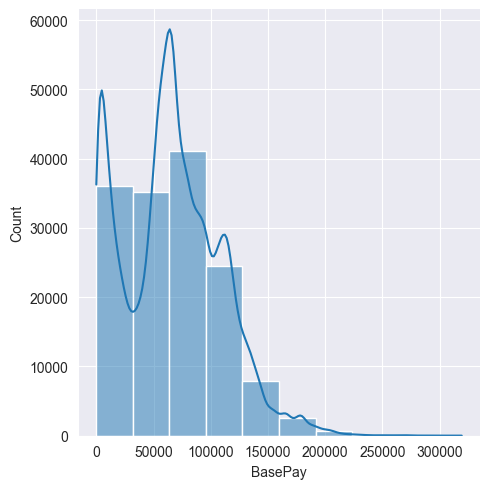

In [11]:
sns.displot(data['BasePay'],kde=True,bins=10)

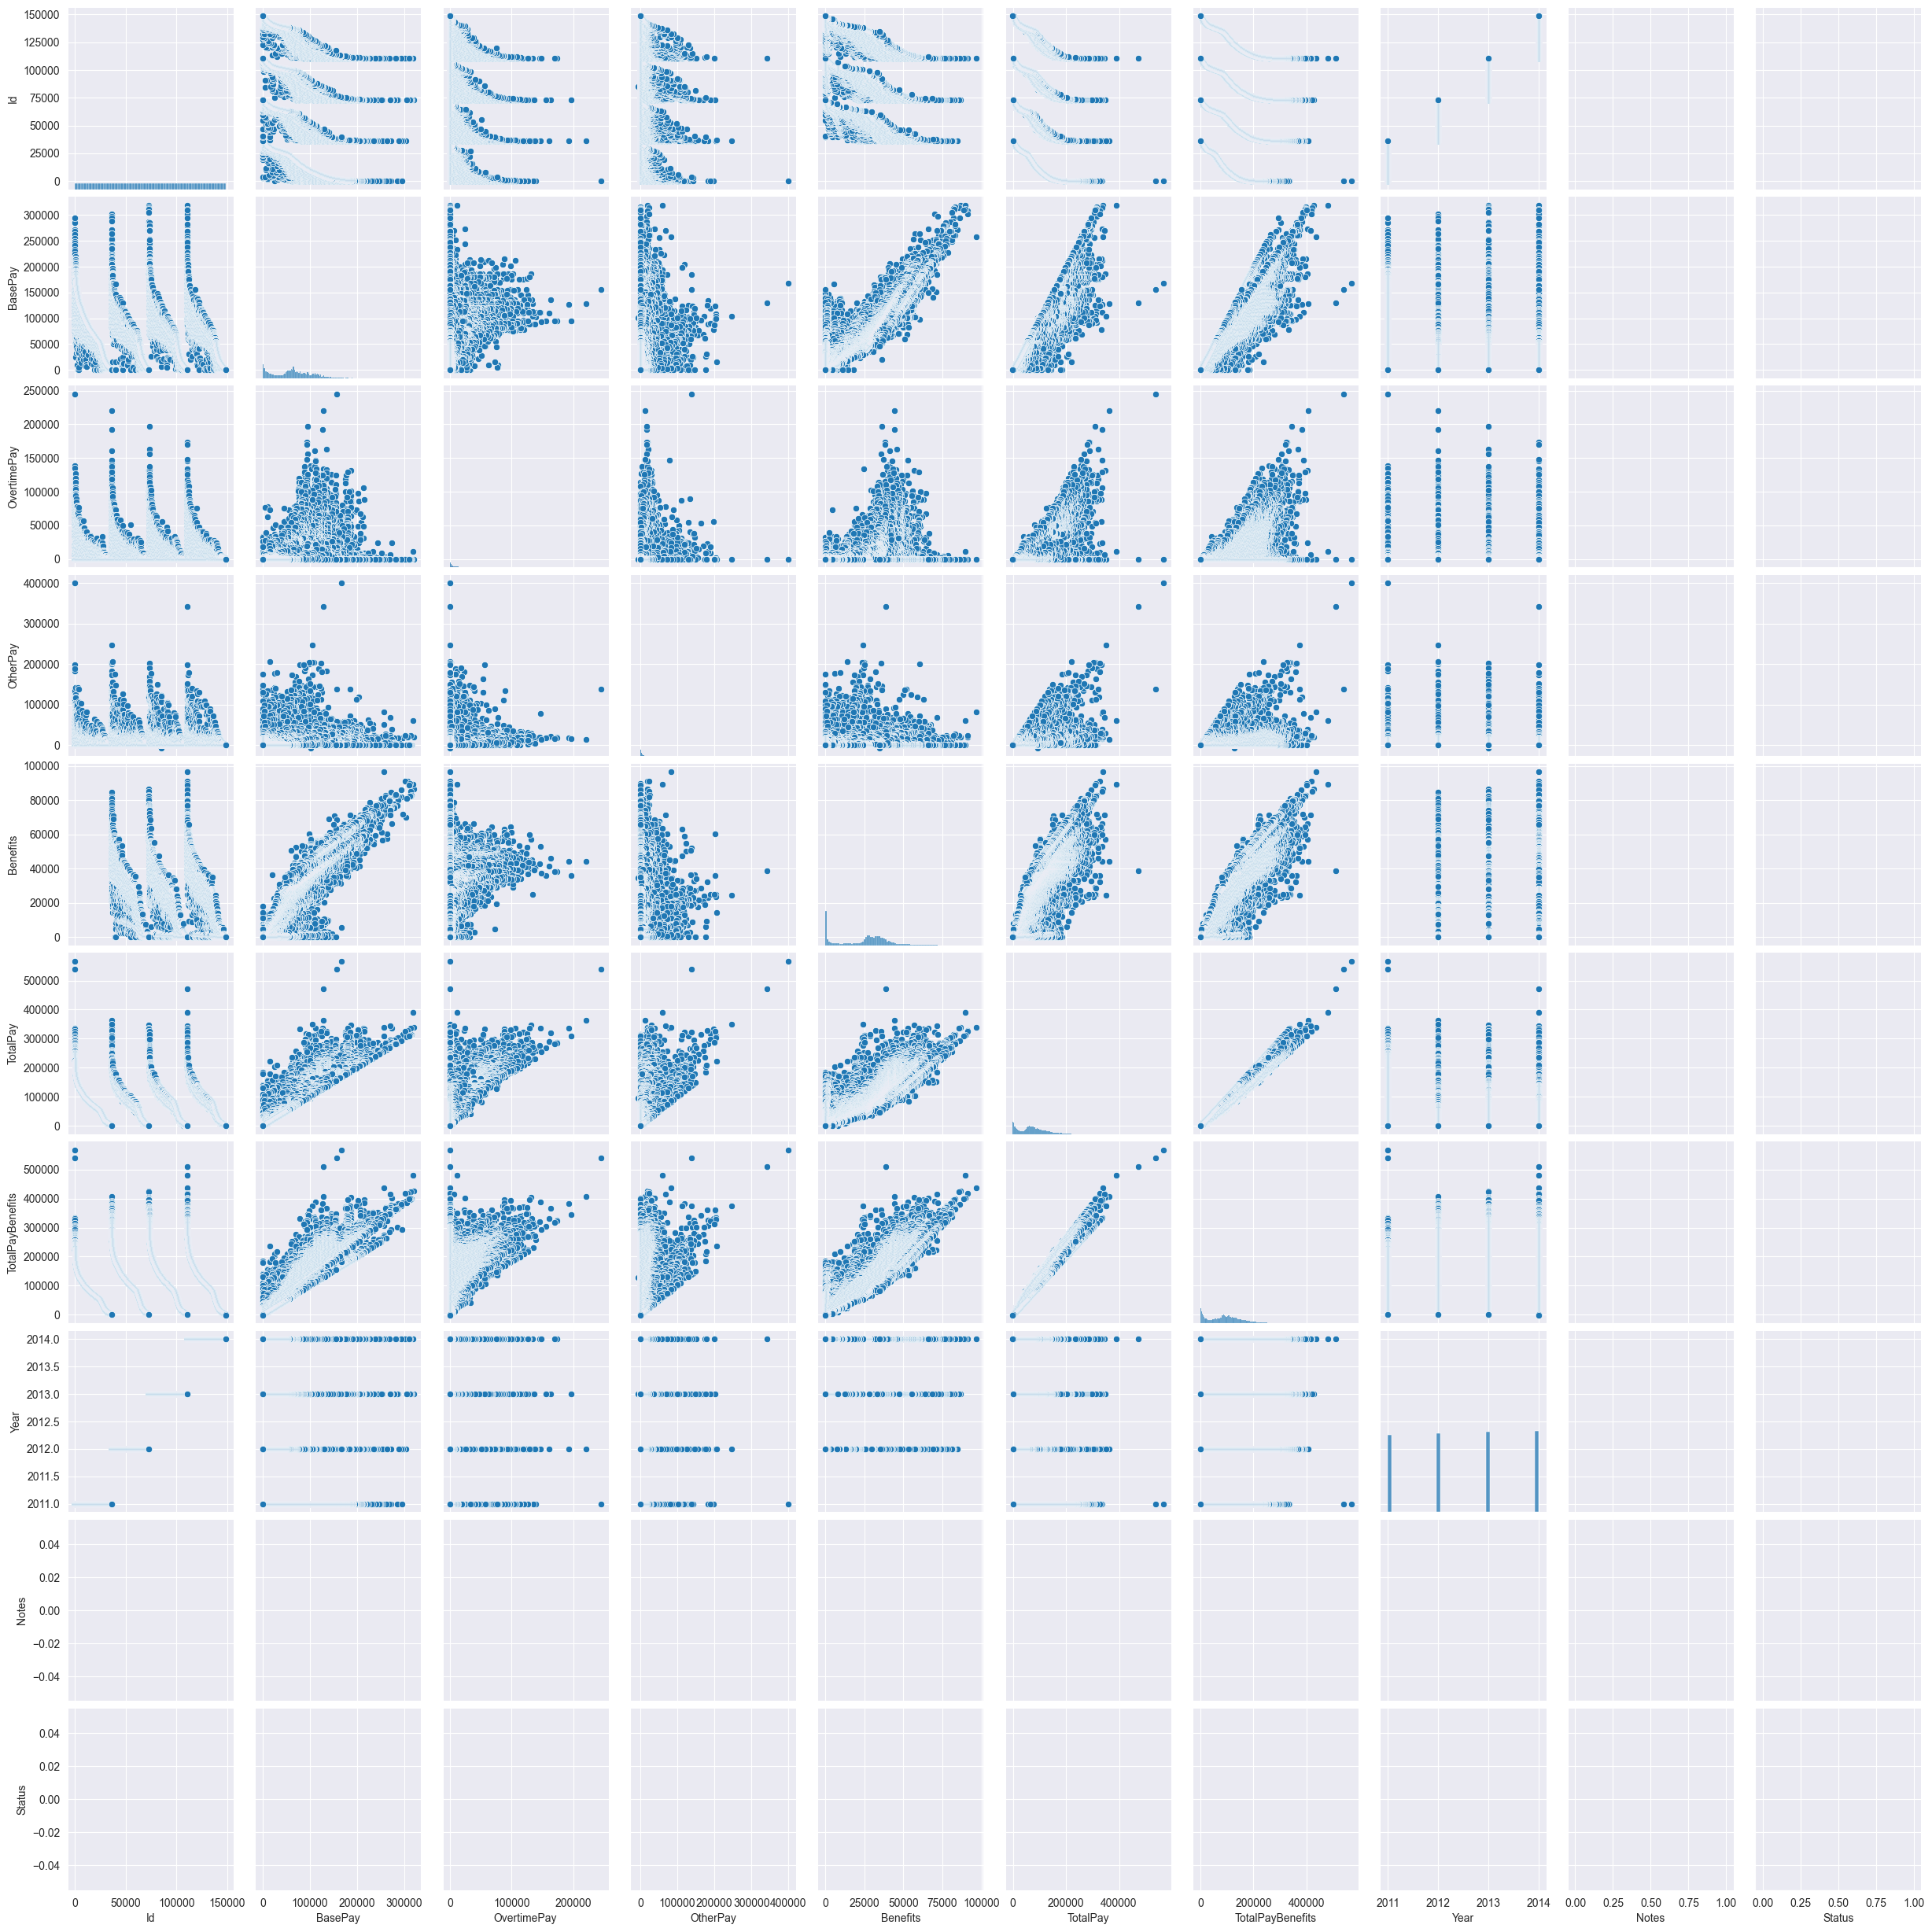

In [12]:
sns.pairplot(data)

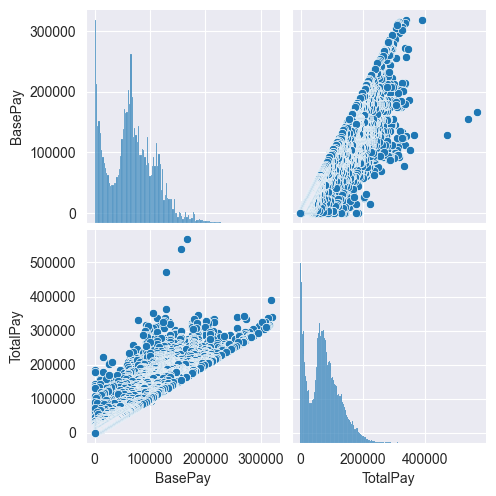

In [13]:
subset = data[['BasePay', 'TotalPay']]
sns.pairplot(subset)

In [14]:
df = pd.read_csv("../data/Titanic.csv")

## barplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. 

<Axes: xlabel='Sex', ylabel='PassengerId'>

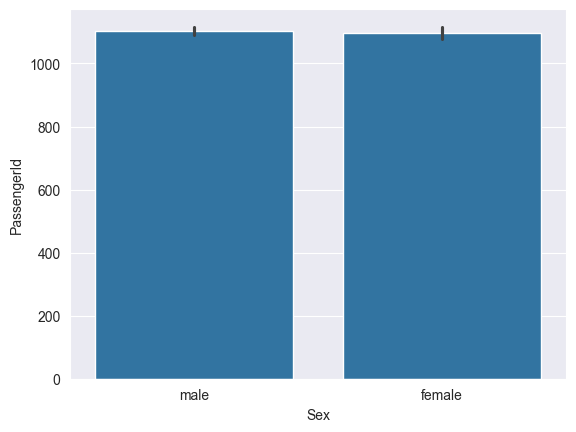

In [30]:
# plt.figure(figsize=(12,4))
sns.barplot(x='Sex',y='PassengerId',data=df)

## boxplot

box plots allow us to choose a numerical variable, like age, and plot the distribution of age for each category in a selected categorical variable.


A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable.

<Axes: xlabel='Sex', ylabel='Age'>

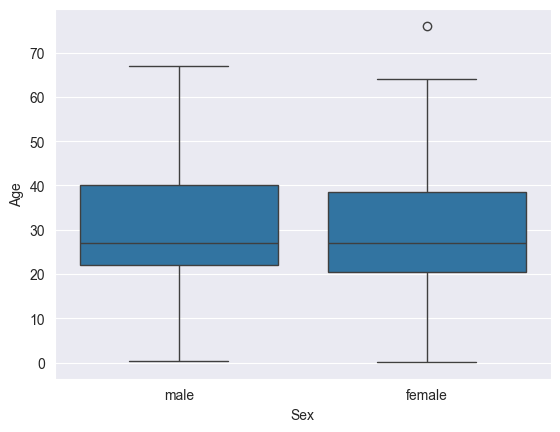

In [16]:
sns.boxplot(x="Sex", y="Age", data=df)

<Axes: >

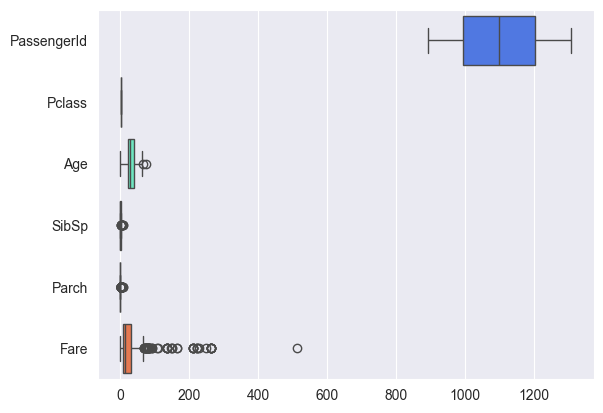

In [17]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=df,palette='rainbow',orient='h')

# Grids
PairGrid allows us to draw a grid of subplots using the same plot type to visualize data.it uses different pair of variable for each subplot. It forms a matrix of sub-plots. It is also sometimes called as “scatterplot matrix”.

## PairGrid
Pairgrid is a subplot grid for plotting pairwise relationships in a dataset.PairGrid. Subplot grid for plotting pairwise relationships in a dataset. This object maps each variable in a dataset onto a column and row in a grid of multiple axes.

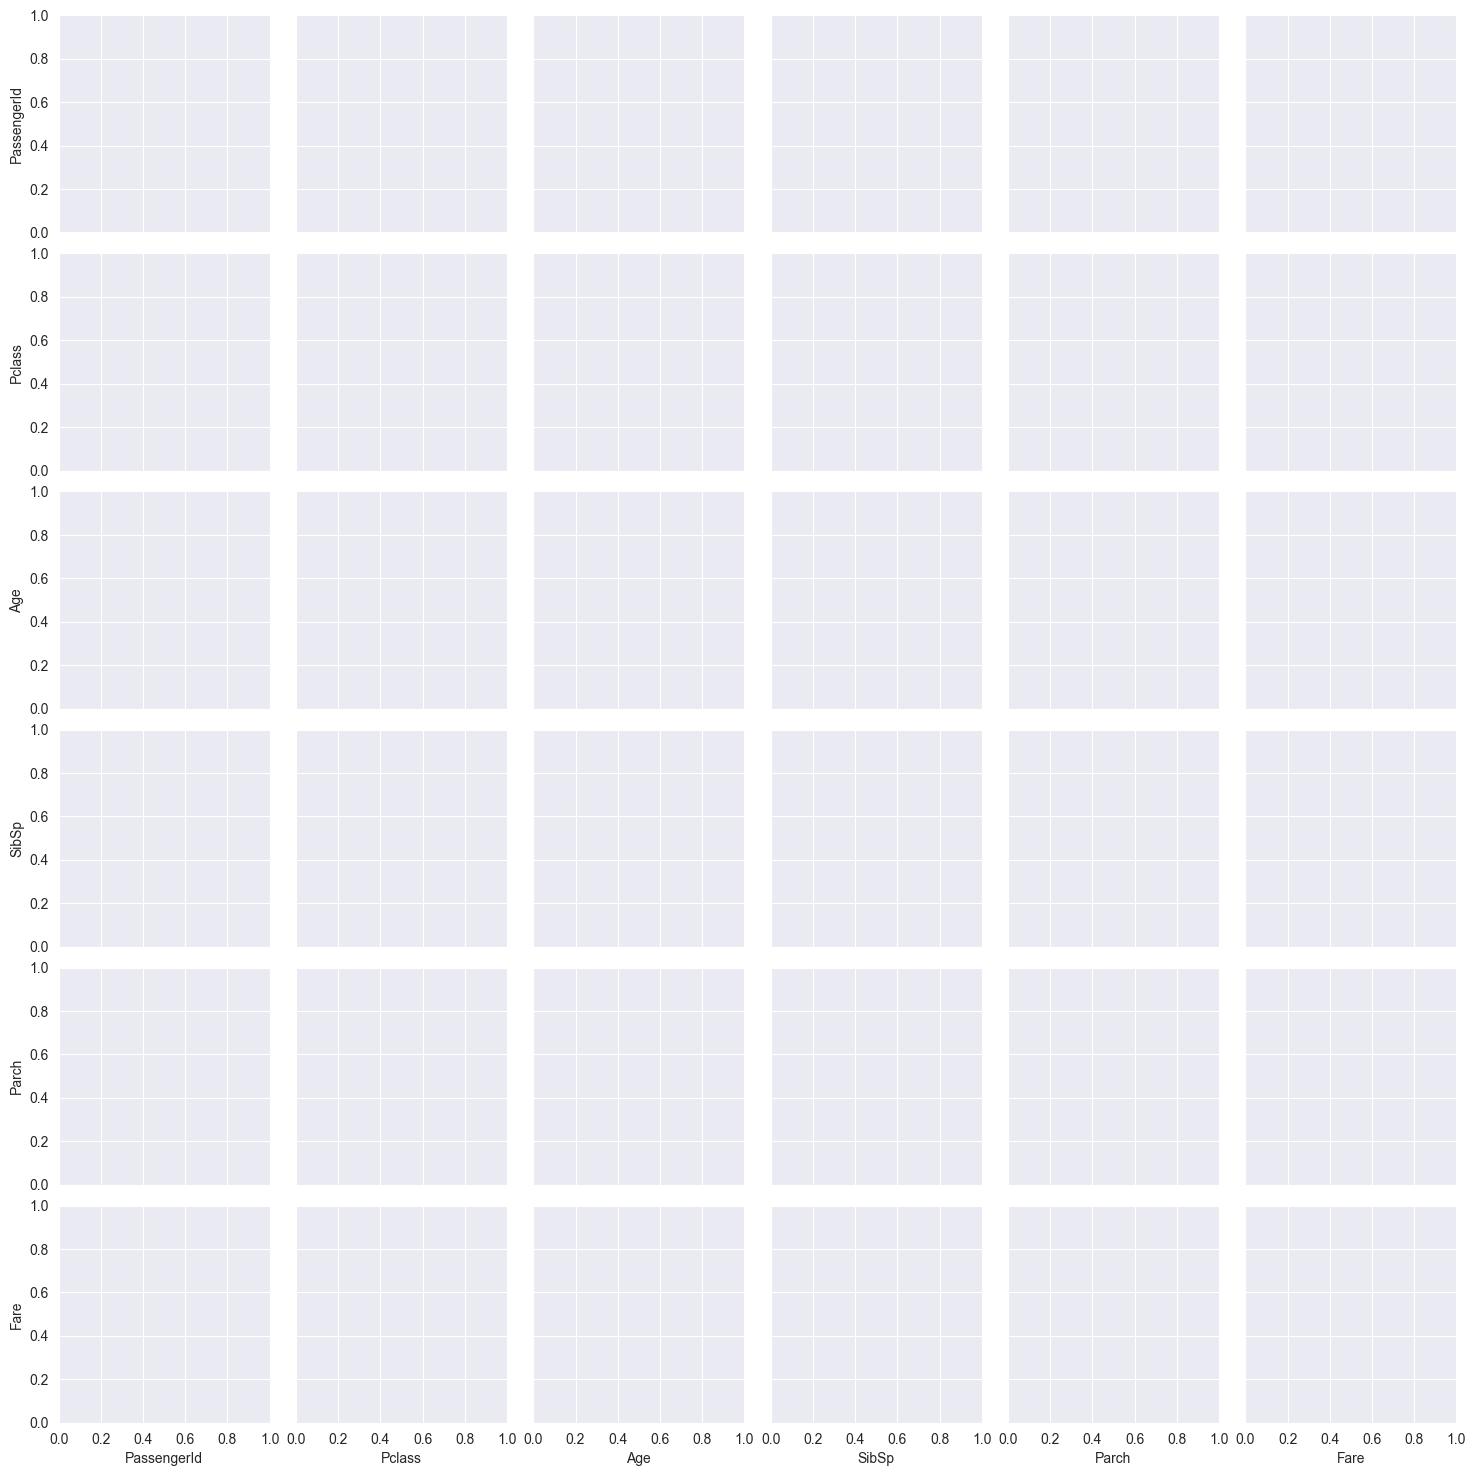

In [18]:
sns.PairGrid(df)

sns.PairGrid(df)

df içindeki tüm sayısal sütunları alır.
Her sütunu hem x hem y eksenine yerleştirerek bir grid (ızgara) oluşturur.
Her hücre bir (x, y) çifti temsil eder.

g.map(plt.scatter)

Her hücreye (yani her değişken çiftine) bir scatter plot (dağılım grafiği) çizer.
Yani plt.scatter() fonksiyonunu grid’in tüm hücrelerine “uygular”.

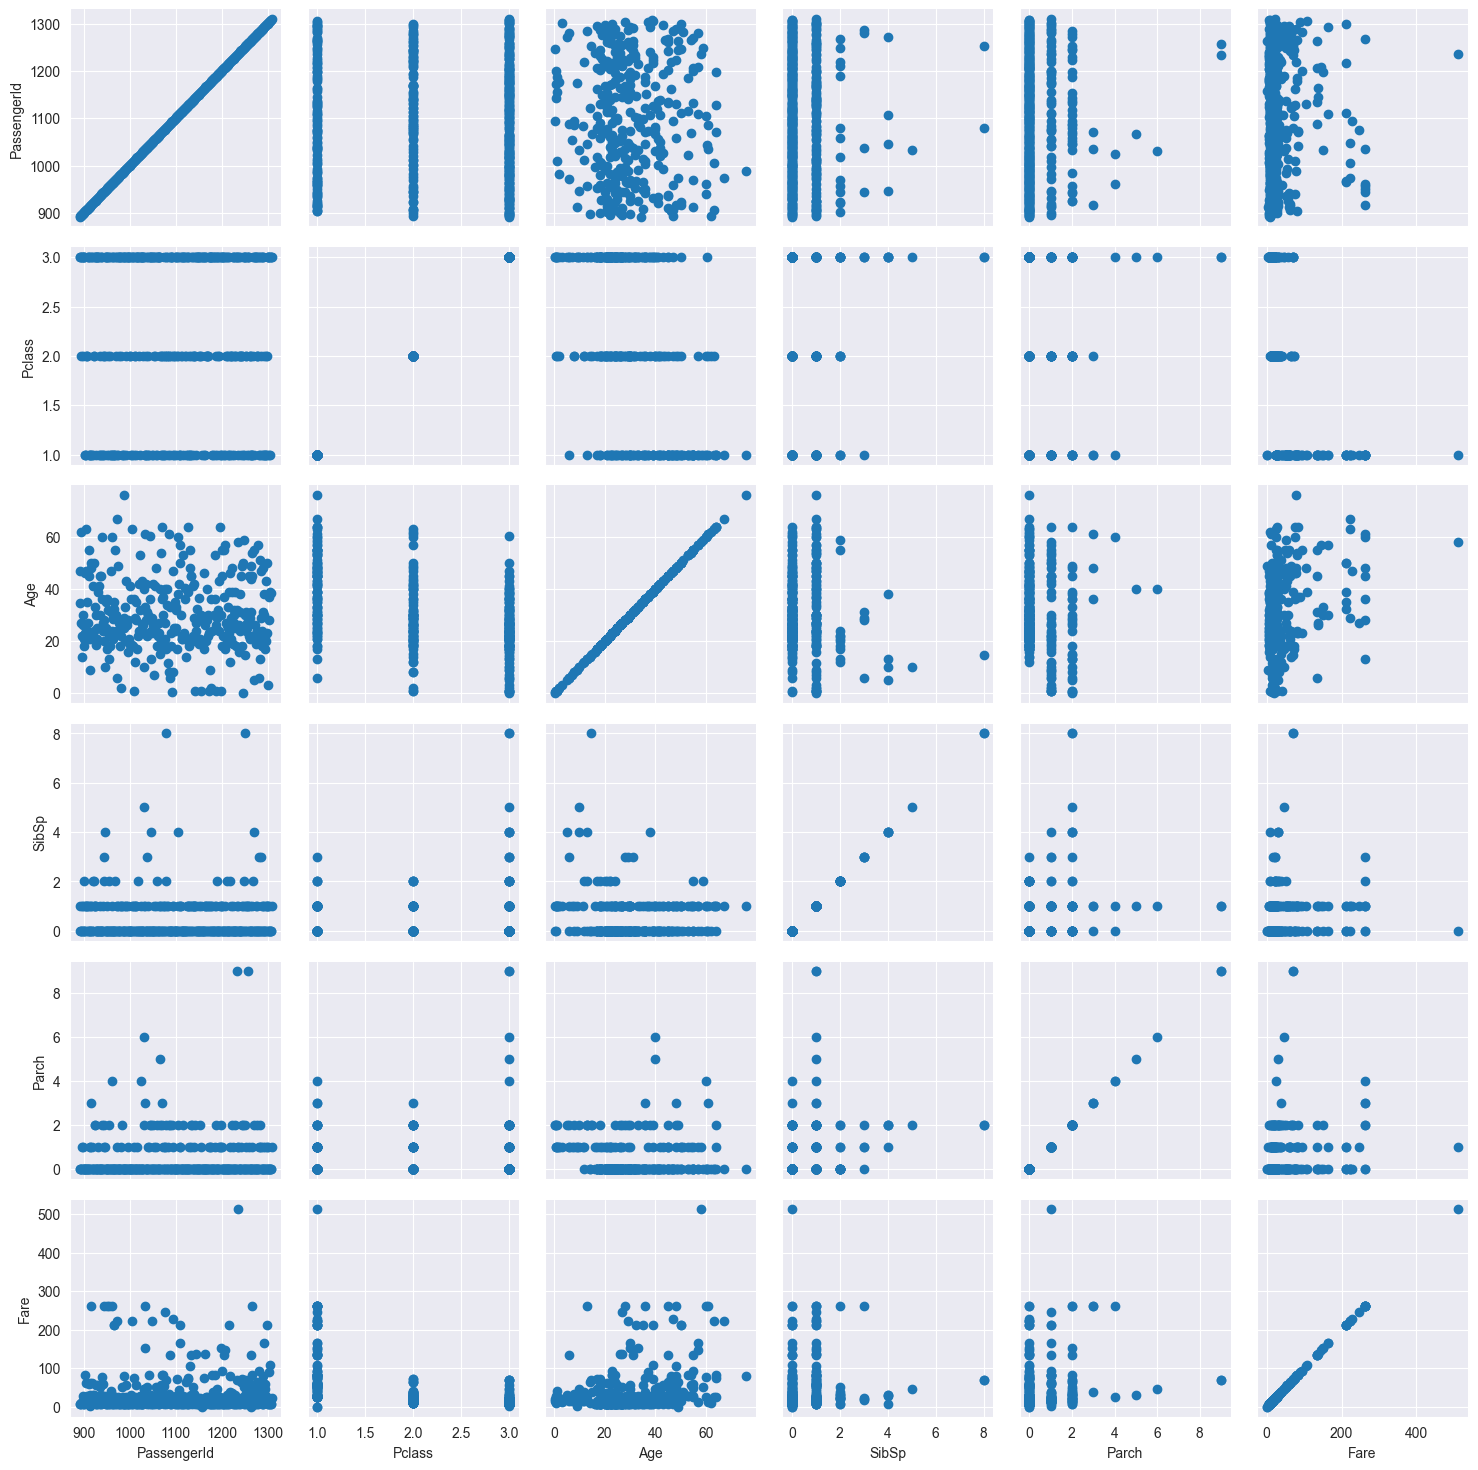

In [19]:
g = sns.PairGrid(df)
g.map(plt.scatter)

           ÜST ÜÇGEN → scatter
           DİYAGONAL → histogram
           ALT ÜÇGEN → kdeplot


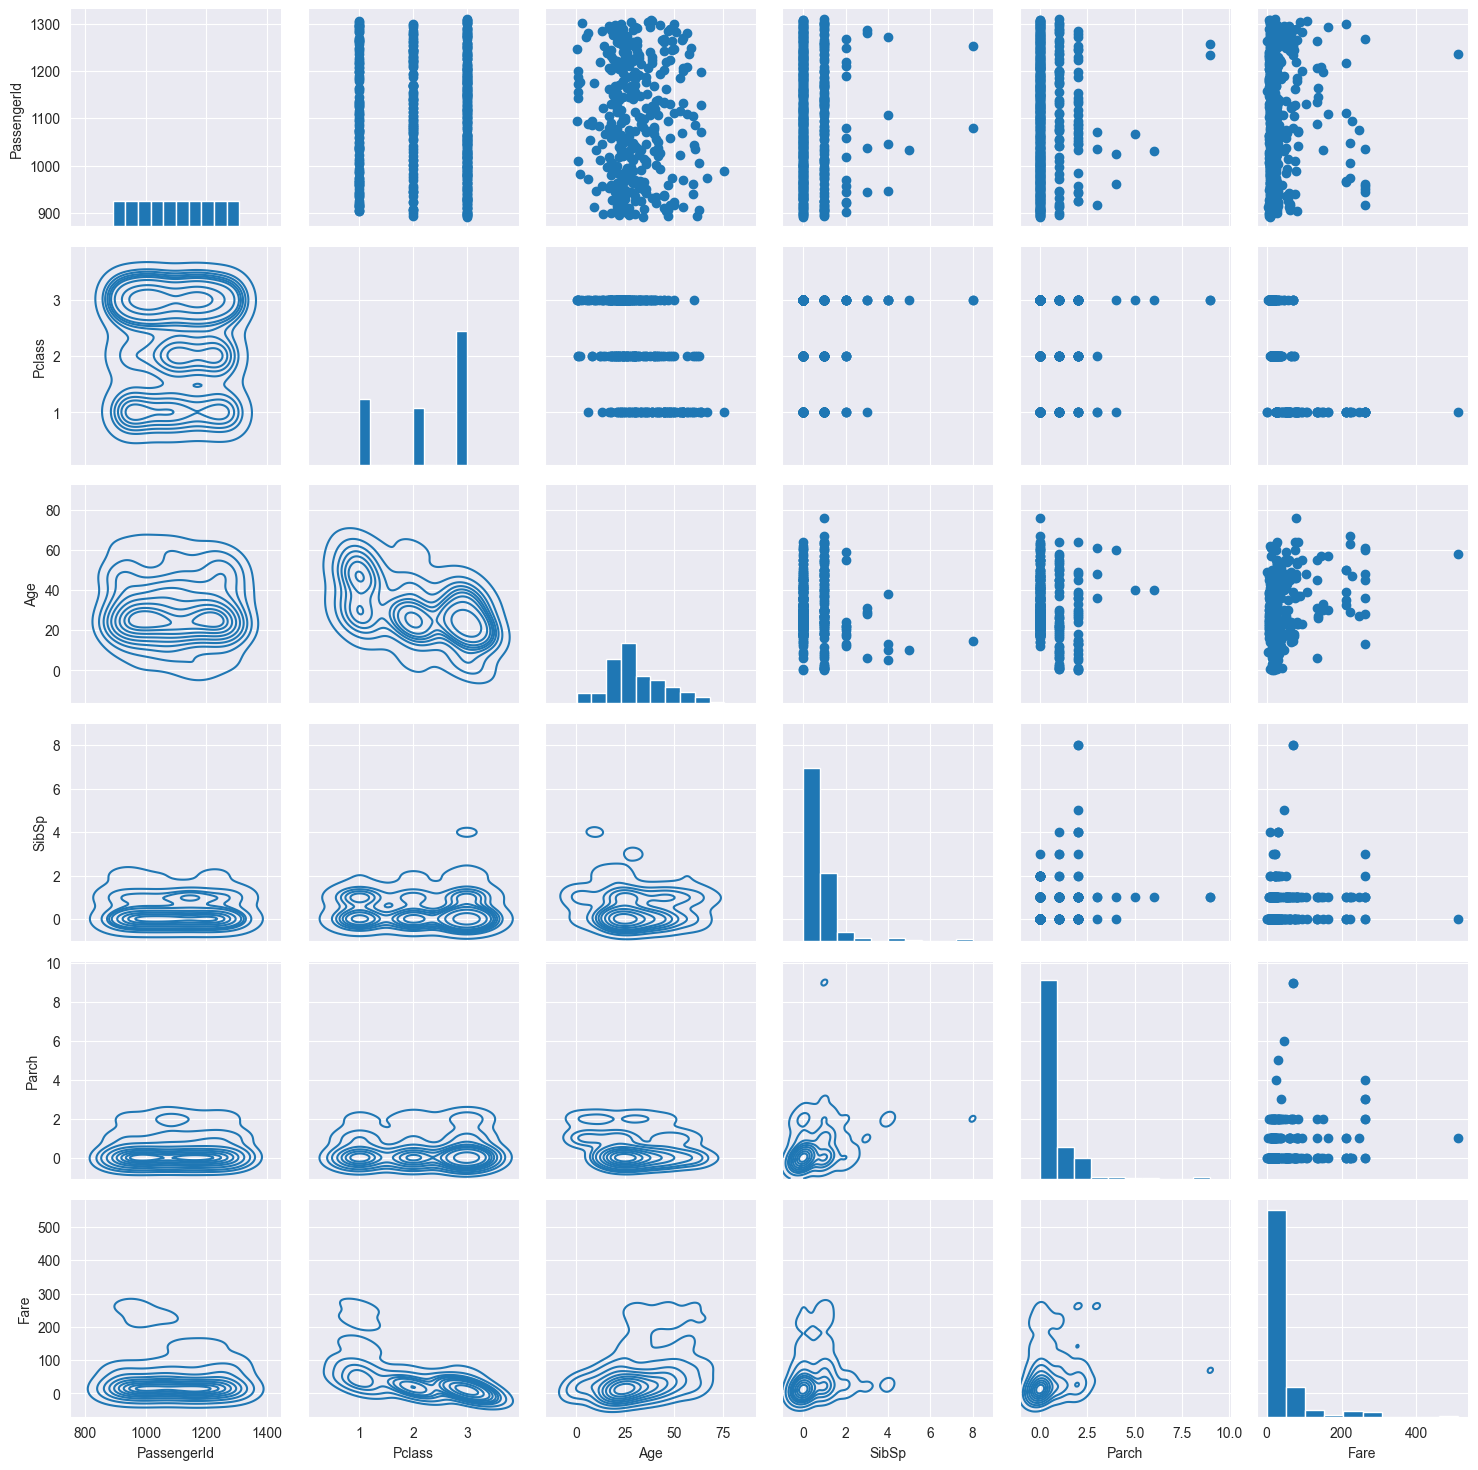

In [20]:
g = sns.PairGrid(df)
g.map_diag(plt.hist)
g.map_upper(plt.scatter)
g.map_lower(sns.kdeplot)

## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [21]:
subset.corr()

,BasePay,TotalPay
BasePay,1.000000,0.954494
TotalPay,0.954494,1.000000


<Axes: >

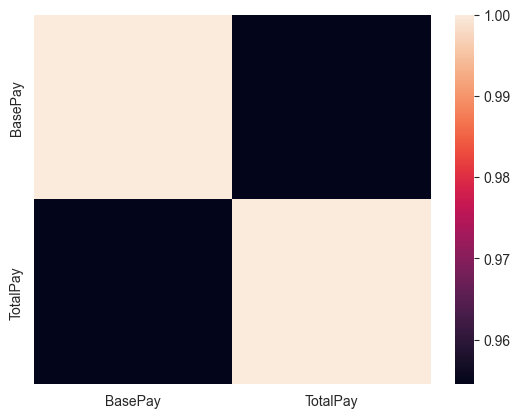

In [22]:
sns.heatmap(subset.corr())

| Parametre         | Anlamı                                                                                                 |
| ----------------- | ------------------------------------------------------------------------------------------------------ |
| `subset.corr()`   | Verideki **sayısal sütunlar arasındaki korelasyon katsayılarını** hesaplar. (–1 ile +1 arası değerler) |
| `cmap='coolwarm'` | Renk paletini belirler → mavi (negatif) ile kırmızı (pozitif) arası geçiş                              |
| `annot=True`      | Her hücrenin **içine sayısal değeri (etiketi)** yazar ✅                                                |


<Axes: >

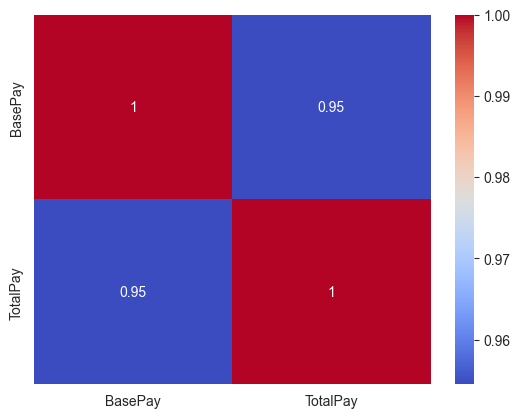

In [23]:
sns.heatmap(subset.corr(),cmap='coolwarm',annot=True)

In [24]:
import scipy
from scipy.stats import pearsonr
from scipy.stats import spearmanr


In [25]:
data.isnull().sum()

Id                       0
EmployeeName             0
JobTitle                 0
BasePay                609
OvertimePay              4
OtherPay                 4
Benefits             36163
TotalPay                 0
TotalPayBenefits         0
Year                     0
Notes               148654
Agency                   0
Status              148654
dtype: int64

In [26]:
pearsonr_coefficient, p_value = pearsonr(data['TotalPayBenefits'], data['TotalPay'])
print('PeasonR Correlation Coefficient %0.3f'% (pearsonr_coefficient))

PeasonR Correlation Coefficient 0.977


In [27]:
spearmanr_coefficient, p_value = spearmanr(data['TotalPayBenefits'], data['TotalPay'])
print('Spearman Rank Correlation Coefficient %0.3f' % (spearmanr_coefficient))

Spearman Rank Correlation Coefficient 0.974
